## Question 4: Evaluating the Position of Women in the Global Labor Force: Participation Rates, Employment Structure, and the Impact of Education

### 4.1. Analytical Objectives

This analysis aims to measure and comprehensively evaluate the position of women in the global labor market across 3 main dimensions:
1. **Participation Trends:** Compare the gap in labor force participation rates between men and women over time.
2. **Employment Structure Shift:** Evaluate whether the shift in female employment (Agriculture -> Industry -> Services) leads to an increase in the proportion of wage and salaried workers (stable jobs).
3. **Impact of Education on Employment Risk:** Test the hypothesis that universalizing tertiary education helps women escape vulnerable employment.

### 4.2. Data Fields Used

**Group 1: Labor Force Participation Rate**
* **`SL.TLF.CACT.FE.ZS`** - Labor force participation rate, female (% of female population ages 15+)
* **`SL.TLF.CACT.MA.ZS`** - Labor force participation rate, male (% of male population ages 15+)
  * *Meaning:* Measures the proportion of the population ages 15 and older that is economically active. The male rate is used as a global baseline to compare the gender gap.

**Group 2: Employment Structure and Stability**
* **`SL.AGR.EMPL.FE.ZS` / `SL.IND.EMPL.FE.ZS` / `SL.SRV.EMPL.FE.ZS`** - Employment in agriculture/industry/services, female (% of female employment)
  * *Meaning:* Shows the distribution of the female workforce across three economic sectors: Agriculture, Industry, and Services.
* **`SL.EMP.WORK.FE.ZS`** - Wage and salaried workers, female (% of female employment)
  * *Meaning:* The percentage of women working as wage and salaried workers (formal sector, with contracts and stable income).

**Group 3: Education and Employment Risk**
* **`SE.TER.ENRR.FE`** - School enrollment, tertiary, female (% gross)
  * *Meaning:* The gross enrollment ratio of females in tertiary education.
* **`SL.EMP.VULN.FE.ZS`** - Vulnerable employment, female (% of female employment)
  * *Meaning:* The percentage of female workers in vulnerable employment (own-account workers and contributing family workers). This serves as a direct measure of "employment risk".

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')


DATA_PATH = 'data3/dataset.csv'
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

# Danh sách các chỉ số cần dùng cho Câu hỏi 4
LABOR_INDICATORS = [
    'SL.TLF.CACT.FE.ZS', 'SL.TLF.CACT.MA.ZS', 
    'SL.AGR.EMPL.FE.ZS', 'SL.IND.EMPL.FE.ZS', 'SL.SRV.EMPL.FE.ZS', 
    'SL.EMP.WORK.FE.ZS', 'SE.TER.ENRR.FE', 'SL.EMP.VULN.FE.ZS'
]


labor_df = df_raw[df_raw['Series Code'].isin(LABOR_INDICATORS)].copy()


year_cols = [c for c in labor_df.columns if c.startswith('20') and c.endswith(']')]
labor_long = labor_df.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='YearRaw', value_name='Value'
)


labor_long['Year'] = labor_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
labor_long['Value'] = pd.to_numeric(labor_long['Value'], errors='coerce')
labor_long = labor_long[labor_long['Year'] <= 2024].reset_index(drop=True)


SELECTED_COUNTRIES = ['NGA', 'RWA', 'SWE', 'USA', 'VNM', 'JPN']
labor_6_countries = labor_long[labor_long['Country Code'].isin(SELECTED_COUNTRIES)].copy()

labor_6_countries['Value'] = labor_6_countries.groupby(['Country Code', 'Series Code'])['Value'].transform(lambda x: x.interpolate(method='linear').ffill().bfill())


print(f"Số giá trị hợp lệ (6 quốc gia): {len(labor_6_countries)}")
print(f"Năm có dữ liệu: {sorted(labor_6_countries['Year'].unique())}")
print(f"Số ô bị thiếu dữ liệu (NaN) sau khi nội suy: {labor_6_countries['Value'].isna().sum()}")


Số giá trị hợp lệ (6 quốc gia): 1200
Năm có dữ liệu: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Số ô bị thiếu dữ liệu (NaN) sau khi nội suy: 0


### 4.3. Detailed Analysis

#### 4.3.1. Labor Force Participation Trends: Females vs. Males

**Chart Type:** Multi-line chart comparing the female labor force participation rate across the 6 representative countries, combined with a Baseline representing the global male average.

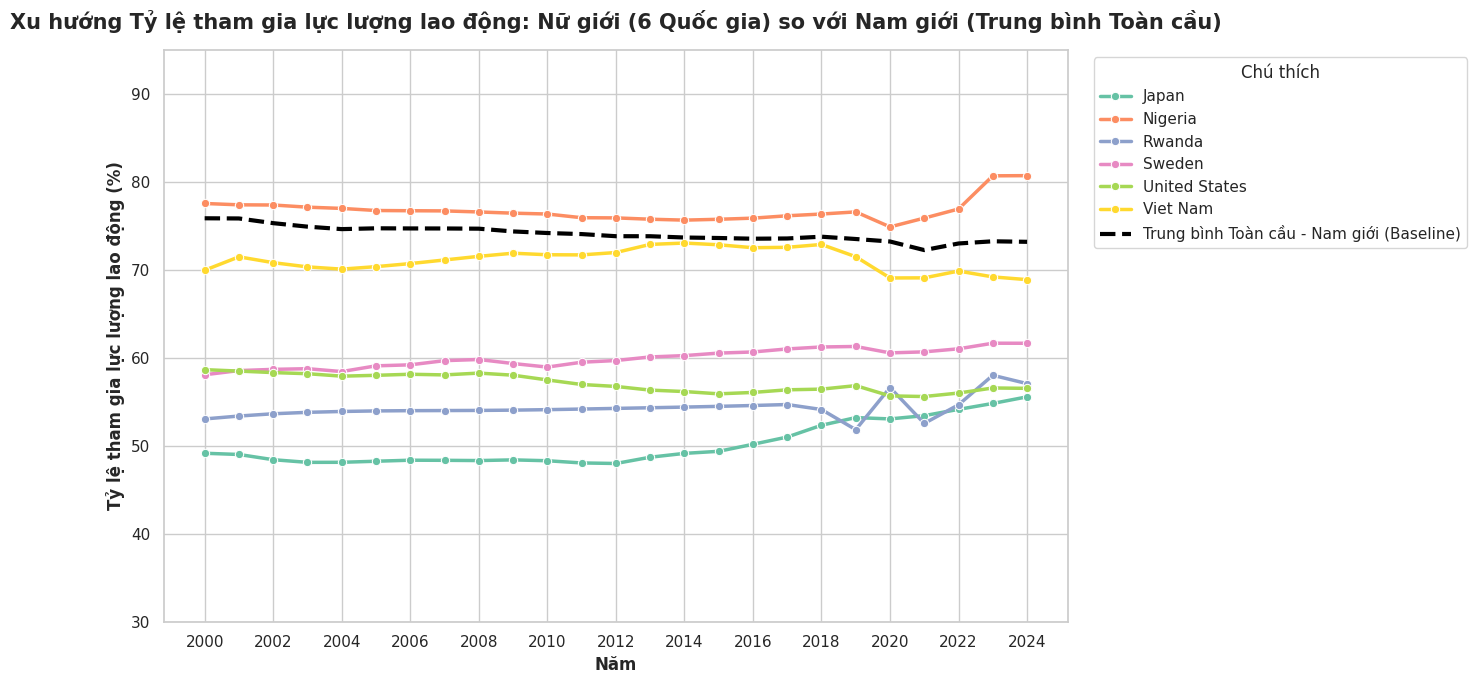

In [56]:

plt.figure(figsize=(14, 7))

# Tính trung bình toàn cầu cho Nam giới 
global_male_lfpr = labor_long[labor_long['Series Code'] == 'SL.TLF.CACT.MA.ZS'].groupby('Year')['Value'].mean().reset_index()

# Nữ giới của 6 quốc gia
female_lfpr_6c = labor_6_countries[labor_6_countries['Series Code'] == 'SL.TLF.CACT.FE.ZS']

# Vẽ đường cho 6 quốc gia (Nữ)
sns.lineplot(
    data=female_lfpr_6c, x='Year', y='Value', hue='Country Name', 
    marker='o', markersize=6, palette='Set2', linewidth=2.5
)

# Vẽ đường Baseline Trung bình Toàn cầu (Nam)
sns.lineplot(
    data=global_male_lfpr, x='Year', y='Value', 
    color='black', linestyle='--', linewidth=3, label='Trung bình Toàn cầu - Nam giới (Baseline)'
)

plt.title('Xu hướng Tỷ lệ tham gia lực lượng lao động: Nữ giới (6 Quốc gia) so với Nam giới (Trung bình Toàn cầu)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Năm', fontsize=12, fontweight='bold')
plt.ylabel('Tỷ lệ tham gia lực lượng lao động (%)', fontsize=12, fontweight='bold')
plt.xticks(range(2000, 2025, 2))
plt.ylim(30, 95)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='Chú thích', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Chart 1 Observations:**
* **Global Male Baseline (Dashed Black Line):** Remained highly stable (around 73-75%) over the two decades, indicating consistent economic participation by men globally.
* **Nigeria and Viet Nam:** Nigeria records the highest female labor participation rate (ranging from 75% to over 80% recently), consistently surpassing the global male average. Viet Nam follows closely, maintaining a high and stable rate of around 70-72%.
* **Sweden, USA, Japan, and Rwanda:** These countries cluster in the 50-60% range. Notably, Japan shows a steady upward trend from 2012 onwards, reflecting the success of policies designed to bring women back into the workforce. Conversely, the United States displays a slow but gradual decline in female participation over the same 24-year period.

#### 4.3.2. Shift in Employment Structure and Wage/Salaried Rates (Global Average)

**Chart Type:** Stacked Area Chart illustrating the agriculture-industry-services composition, overlaid with a Line Chart showing the percentage of female wage and salaried workers.

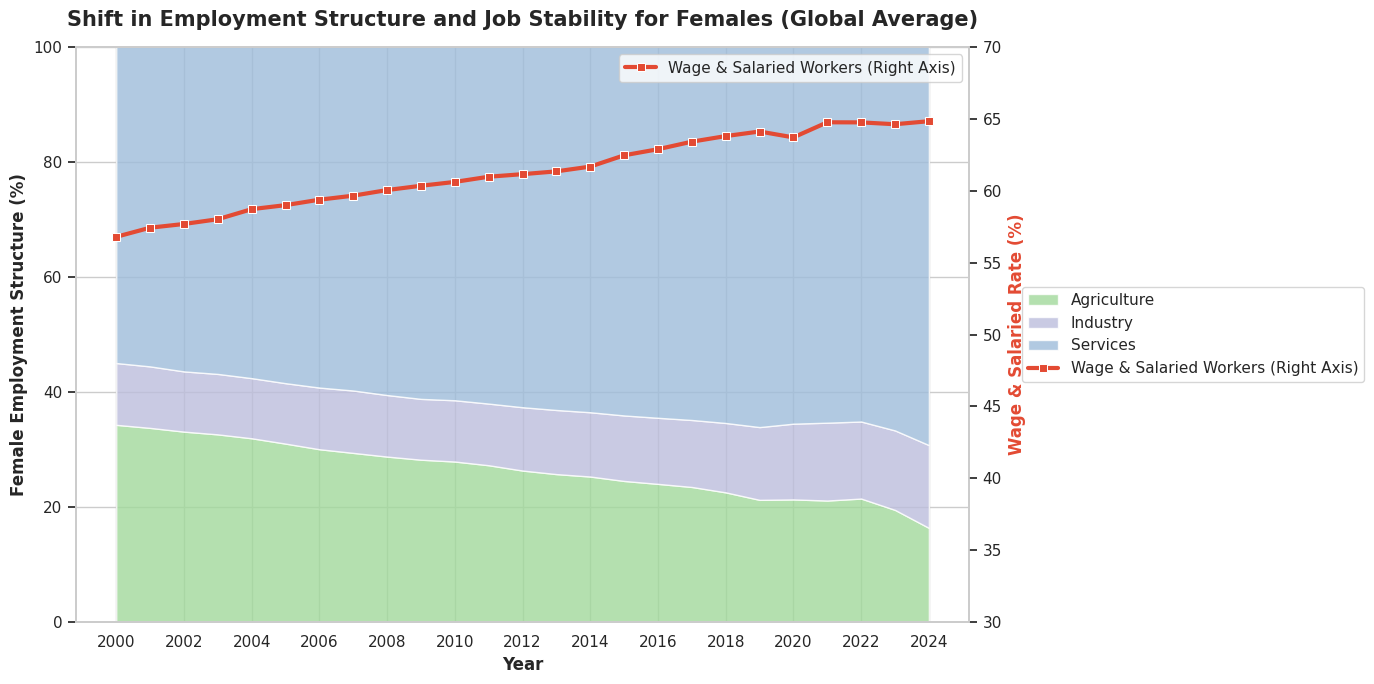

In [57]:
sectors = ['SL.AGR.EMPL.FE.ZS', 'SL.IND.EMPL.FE.ZS', 'SL.SRV.EMPL.FE.ZS', 'SL.EMP.WORK.FE.ZS']

global_structure = labor_long[labor_long['Series Code'].isin(sectors)].groupby(['Year', 'Series Code'])['Value'].mean().unstack().reset_index()


for sector in sectors:
    if sector not in global_structure.columns:
        global_structure[sector] = 0

global_structure = global_structure.dropna()

fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.stackplot(global_structure['Year'], 
              global_structure['SL.AGR.EMPL.FE.ZS'], 
              global_structure['SL.IND.EMPL.FE.ZS'], 
              global_structure['SL.SRV.EMPL.FE.ZS'], 
              labels=['Agriculture', 'Industry', 'Services'], 
              colors=['#a1d99b', '#bcbddc', '#9ebcda'], alpha=0.8)

ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Female Employment Structure (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.set_xticks(range(2000, 2025, 2))

# Trục 2: Vẽ Line Chart cho Wage and Salaried workers
ax2 = ax1.twinx()
sns.lineplot(data=global_structure, x='Year', y='SL.EMP.WORK.FE.ZS', 
             color='#e34a33', marker='s', linewidth=3, ax=ax2, label='Wage & Salaried Workers (Right Axis)')

ax2.set_ylabel('Wage & Salaried Rate (%)', fontsize=12, fontweight='bold', color='#e34a33')
ax2.set_ylim(30, 70) 
ax2.grid(False) 

# Combine Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center left', bbox_to_anchor=(1.05, 0.5))

plt.title('Shift in Employment Structure and Job Stability for Females (Global Average)', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()



**Chart 2 Observations:**
* **Dominance and Expansion of the Services Sector:** The blue area (Services) consistently expands over the years, eating heavily into the Agriculture sector (green area), which shrinks from over 30% down to roughly 15%. The Industrial sector (purple) remains relatively thin and stagnant. This highlights a global urbanization trend pulling women from the fields into the service economy.
* **Correlation with Job Stability:** The red line (Wage and Salaried Workers) trends upward from under 60% to approximately 65%, moving in parallel with the growth of the services sector. This structural shift has brought a positive impact: Women are transitioning from self-sufficient rural labor to contracted, salaried positions, thereby increasing their financial independence.

#### 4.3.3. Impact of Tertiary Education on Female Employment Risk

**Chart Type:** Grouped Bar Chart comparing Tertiary Enrollment (blue bars) and Vulnerable Employment (red bars) for females in representative countries in the year 2020. *(Note: Some countries were excluded from this specific chart due to missing 2020 data for these exact indicators).*

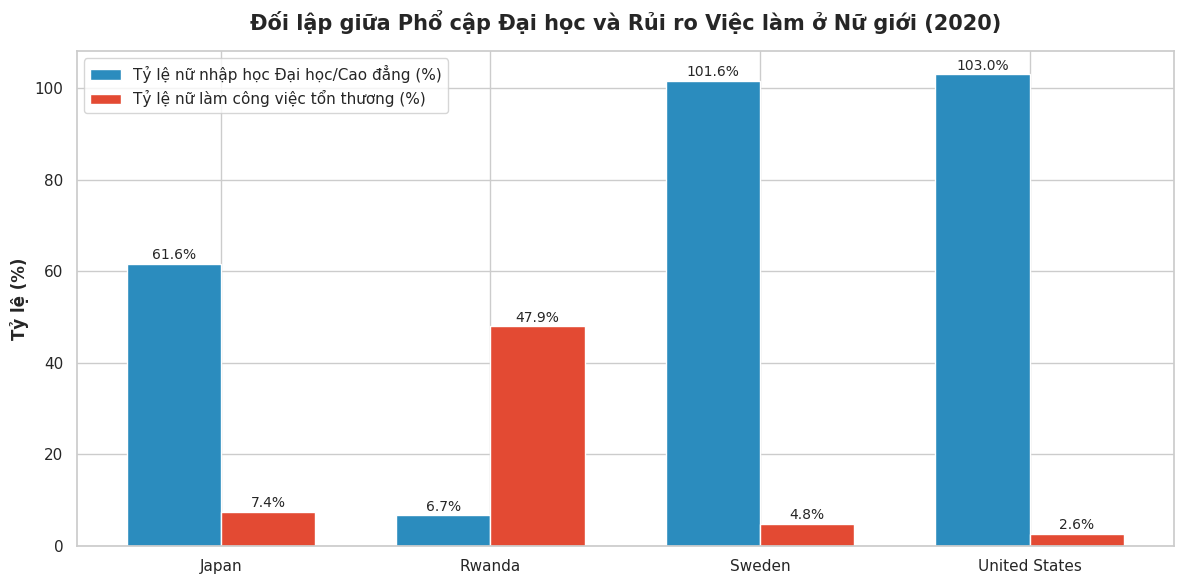

In [58]:
TARGET_YEAR = 2020
edu_vuln_df = labor_long[(labor_long['Year'] == TARGET_YEAR) & 
                         (labor_long['Series Code'].isin(['SE.TER.ENRR.FE', 'SL.EMP.VULN.FE.ZS']))].copy()

# Pivot data
pivot_edu_vuln = edu_vuln_df.pivot(index=['Country Name', 'Country Code'], 
                                   columns='Series Code', values='Value').reset_index()

rename_dict = {}
if 'SE.TER.ENRR.FE' in pivot_edu_vuln.columns:
    rename_dict['SE.TER.ENRR.FE'] = 'Tertiary_Edu'
if 'SL.EMP.VULN.FE.ZS' in pivot_edu_vuln.columns:
    rename_dict['SL.EMP.VULN.FE.ZS'] = 'Vulnerable_Emp'
pivot_edu_vuln.rename(columns=rename_dict, inplace=True)

pivot_edu_vuln = pivot_edu_vuln.dropna()

plt.figure(figsize=(12, 6))

x = np.arange(len(pivot_edu_vuln['Country Name']))
width = 0.35

plt.bar(x - width/2, pivot_edu_vuln['Tertiary_Edu'], width, label='Tỷ lệ nữ nhập học Đại học/Cao đẳng (%)', color='#2b8cbe')
plt.bar(x + width/2, pivot_edu_vuln['Vulnerable_Emp'], width, label='Tỷ lệ nữ làm công việc tổn thương (%)', color='#e34a33')


plt.title('Đối lập giữa Phổ cập Đại học và Rủi ro Việc làm ở Nữ giới (2020)', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Tỷ lệ (%)', fontsize=12, fontweight='bold')
plt.xticks(x, pivot_edu_vuln['Country Name'], fontsize=11)
plt.legend(fontsize=11)

for i in x:
    plt.text(i - width/2, pivot_edu_vuln['Tertiary_Edu'].iloc[i] + 1, f"{pivot_edu_vuln['Tertiary_Edu'].iloc[i]:.1f}%", ha='center', fontsize=10)
    plt.text(i + width/2, pivot_edu_vuln['Vulnerable_Emp'].iloc[i] + 1, f"{pivot_edu_vuln['Vulnerable_Emp'].iloc[i]:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Chart 3 Observations:**
* **A Stark Contrast:** The bar chart reveals a crystal-clear inverse relationship. Countries with high female tertiary education enrollment display exceptionally low vulnerable employment rates, and vice versa. 
* **Developed vs. Developing Profiles:** The United States, Sweden, and Japan boast high tertiary enrollment (over 60%, with Sweden and the US exceeding 100% due to gross enrollment metrics including mature students). Consequently, their female vulnerable employment rates are negligible (under 8%). In stark contrast, Rwanda presents an alarming profile: only 6.7% of females are enrolled in tertiary education, leaving nearly 48% trapped in vulnerable, precarious employment.
* **The "Educational Shield":** The data visually confirms that higher education acts as the strongest "shield" for women, practically guaranteeing entry into the formal, stable labor sector rather than risky, unpaid, or informal labor.

### 4.4. General Conclusions and Limitations

**4.4.1. General Conclusions**
Synthesizing the three analyses above, we can draw a comprehensive picture of the female labor force:
* Although the female labor force participation rate still varies drastically by region (and generally lags behind men), the **quality** of their employment is improving over time globally, driven by a massive shift away from agriculture into the services sector.
* **Education is the vital key.** In the labor market, a higher education degree is an almost absolute guarantee for women to escape risky, unpaid, or precarious work (as proven by the stark contrasts in Chart 3). 

**4.4.2. Limitations of the Analysis**
* The `Labor Force Participation Rate` statistic **completely overlooks unpaid domestic labor.** Women staying home to care for children and manage households handle a massive workload that sustains the economy, yet statistically, they are classified as "economically inactive."
* The `Wage and salaried workers` indicator merely counts those with formal contracts but **fails to reflect the Gender Wage Gap.** Women may hold formal office positions identical to men but still receive lower compensation for the exact same role.